In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Section 1 — Timeseries Review

In [2]:
# MAIN
from utils import (load_q_diepoldsau, load_q_gisingen,
                   load_ssc_diepoldsau, load_ssc_gisingen,
                   compute_monthly_mean, detrend_series)

# Load and resample to monthly means
q_diep   = compute_monthly_mean(load_q_diepoldsau())["Q"]
q_gis    = compute_monthly_mean(load_q_gisingen())["Q"]
ssc_diep = compute_monthly_mean(load_ssc_diepoldsau())["SSC"]
ssc_gis  = compute_monthly_mean(load_ssc_gisingen())["SSC"]

# Detrend: subtract significant linear trend (p<0.05) or mean
q_diep_dt,   t_q_diep   = detrend_series(q_diep)
q_gis_dt,    t_q_gis    = detrend_series(q_gis)
ssc_diep_dt, t_ssc_diep = detrend_series(ssc_diep)
ssc_gis_dt,  t_ssc_gis  = detrend_series(ssc_gis)

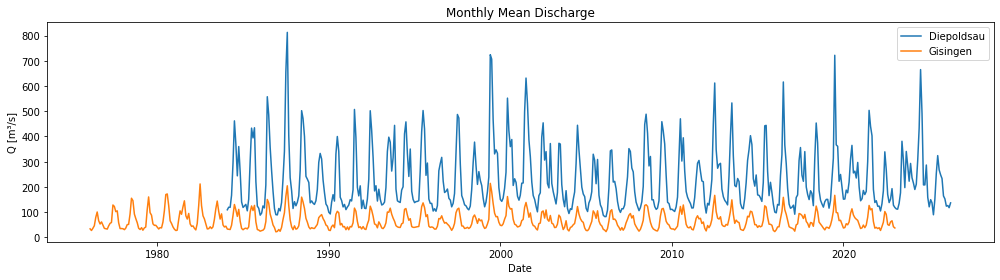

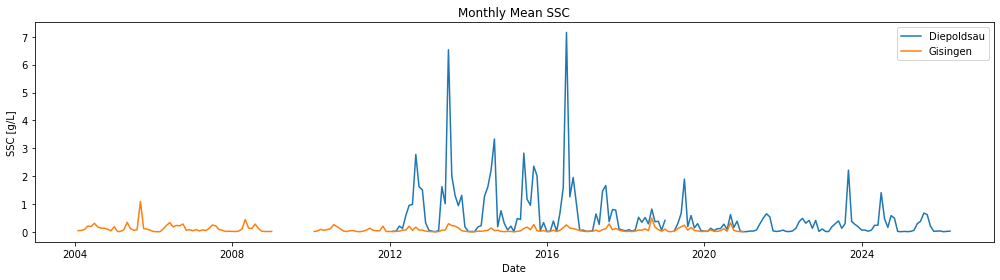

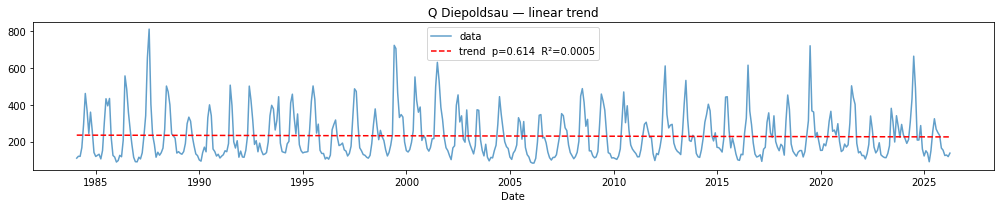

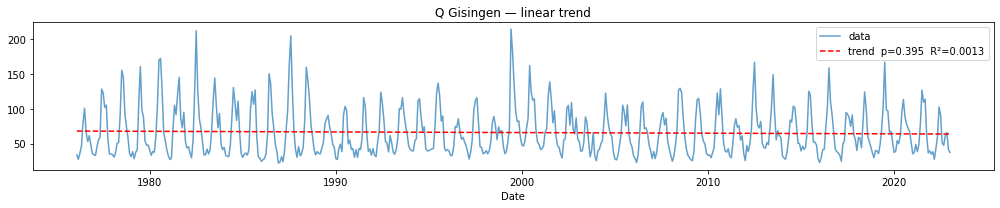

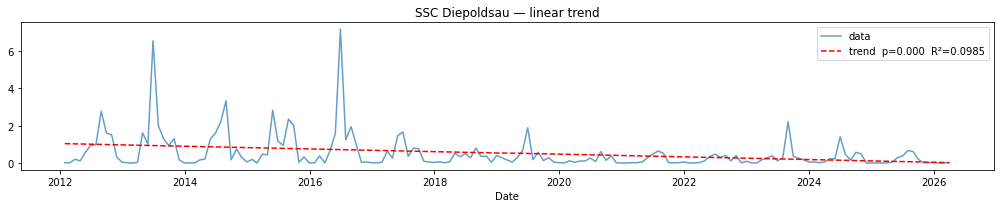

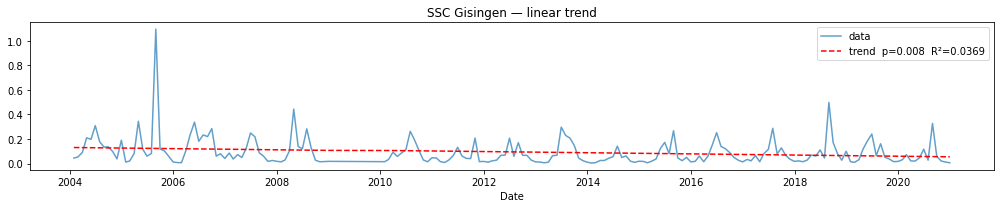

In [3]:
# PLOT
from utils import plot_timeseries, plot_trend_fit

plot_timeseries({"Diepoldsau": q_diep, "Gisingen": q_gis},
                ylabel="Q [m\u00b3/s]", title="Monthly Mean Discharge")
plot_timeseries({"Diepoldsau": ssc_diep, "Gisingen": ssc_gis},
                ylabel="SSC [g/L]", title="Monthly Mean SSC")
plot_trend_fit(q_diep,   t_q_diep,   title="Q Diepoldsau — linear trend")
plot_trend_fit(q_gis,    t_q_gis,    title="Q Gisingen — linear trend")
plot_trend_fit(ssc_diep, t_ssc_diep, title="SSC Diepoldsau — linear trend")
plot_trend_fit(ssc_gis,  t_ssc_gis,  title="SSC Gisingen — linear trend")
plt.show()

In [4]:
# PRINT
rows = [
    ("Q Diepoldsau",    t_q_diep),
    ("Q Gisingen",      t_q_gis),
    ("SSC Diepoldsau",  t_ssc_diep),
    ("SSC Gisingen",    t_ssc_gis),
]
df_trend = pd.DataFrame([{
    "Series":            name,
    "Slope (per month)": f"{t['slope']:.4e}",
    "p-value":           f"{t['p_value']:.4f}",
    "R\u00b2":           f"{t['r_squared']:.4f}",
    "Significant (5%)": t['significant'],
    "Detrending":        "trend subtracted" if t['significant'] else "mean subtracted"
} for name, t in rows])
print(df_trend.to_string(index=False))

        Series Slope (per month) p-value     R²  Significant (5%)       Detrending
  Q Diepoldsau       -1.9002e-02  0.6136 0.0005             False  mean subtracted
    Q Gisingen       -7.5179e-03  0.3952 0.0013             False  mean subtracted
SSC Diepoldsau       -6.0277e-03  0.0000 0.0985              True trend subtracted
  SSC Gisingen       -3.9611e-04  0.0076 0.0369              True trend subtracted


**Comments — Section 1:**

Neither discharge series shows a statistically significant trend (Q Diepoldsau: p = 0.61, Q Gisingen: p = 0.40), so the mean was subtracted. Both Q series can be considered stationary in the mean over their observation period, suggesting no long-term change in the flow regime at either station.

Both SSC series show statistically significant negative trends (SSC Diepoldsau: p ≈ 0, R² = 0.10; SSC Gisingen: p = 0.008, R² = 0.04), so the linear trend was subtracted. Suspended sediment concentrations have been declining over time at both stations. This is unlikely to be a measuring error — it is consistent with well-documented physical processes in Alpine catchments: river channelisation, bank protection works, and upstream reservoir trapping reduce the availability of sediment. In the case of the Ill, partial regulation by the Illspitz Kraftwerk may additionally trap fine sediment, contributing to the observed decline at Gisingen.

# Section 2 — Timeseries Modelling

In [5]:
# MAIN
from utils import (compute_acf_pacf, select_ar_order, select_arma_order,
                   fit_ar, fit_arma)

# Empirical ACF / PACF — 48 lags to capture seasonal structure
corr_q_diep   = compute_acf_pacf(q_diep_dt,   lags=48)
corr_q_gis    = compute_acf_pacf(q_gis_dt,    lags=48)
corr_ssc_diep = compute_acf_pacf(ssc_diep_dt, lags=48)
corr_ssc_gis  = compute_acf_pacf(ssc_gis_dt,  lags=48)

# Select AR orders by AIC (up to p=13 to cover seasonal lag 12)
p_ar_q_diep,   aic_ar_q_diep   = select_ar_order(q_diep_dt)
p_ar_q_gis,    aic_ar_q_gis    = select_ar_order(q_gis_dt)
p_ar_ssc_diep, aic_ar_ssc_diep = select_ar_order(ssc_diep_dt)
p_ar_ssc_gis,  aic_ar_ssc_gis  = select_ar_order(ssc_gis_dt)

# Select ARMA orders by AIC
p_arma_q_diep,   q_arma_q_diep,   _ = select_arma_order(q_diep_dt)
p_arma_q_gis,    q_arma_q_gis,    _ = select_arma_order(q_gis_dt)
p_arma_ssc_diep, q_arma_ssc_diep, _ = select_arma_order(ssc_diep_dt)
p_arma_ssc_gis,  q_arma_ssc_gis,  _ = select_arma_order(ssc_gis_dt)

# Fit models
ar_q_diep    = fit_ar(q_diep_dt,   p_ar_q_diep)
ar_q_gis     = fit_ar(q_gis_dt,    p_ar_q_gis)
ar_ssc_diep  = fit_ar(ssc_diep_dt, p_ar_ssc_diep)
ar_ssc_gis   = fit_ar(ssc_gis_dt,  p_ar_ssc_gis)

arma_q_diep   = fit_arma(q_diep_dt,   p_arma_q_diep,   q_arma_q_diep)
arma_q_gis    = fit_arma(q_gis_dt,    p_arma_q_gis,    q_arma_q_gis)
arma_ssc_diep = fit_arma(ssc_diep_dt, p_arma_ssc_diep, q_arma_ssc_diep)
arma_ssc_gis  = fit_arma(ssc_gis_dt,  p_arma_ssc_gis,  q_arma_ssc_gis)

C:\Users\zehnd\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\zehnd\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\zehnd\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


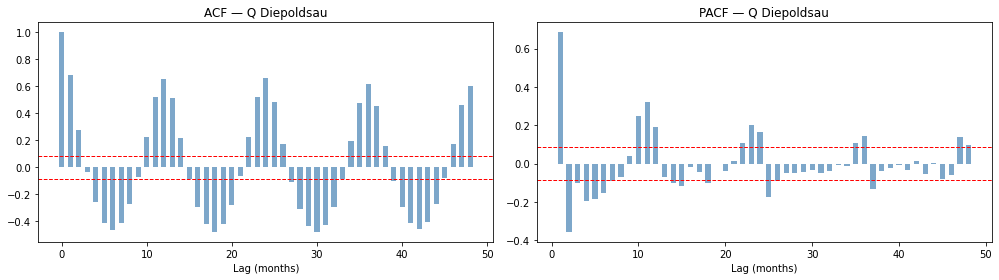

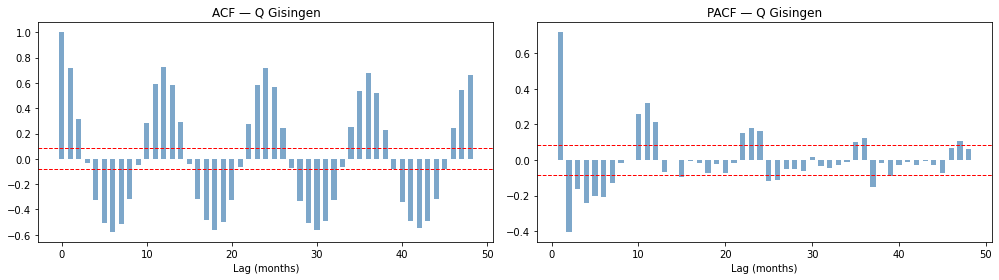

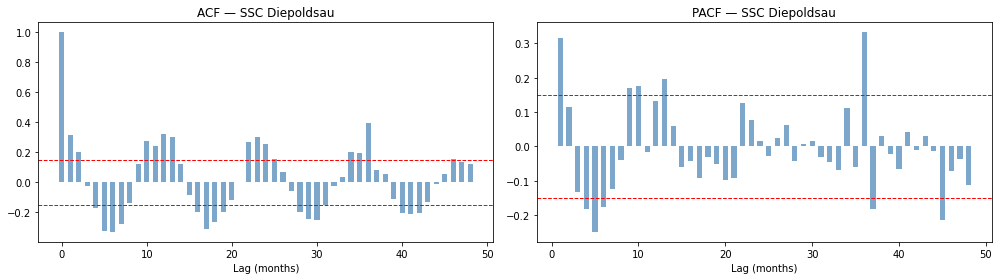

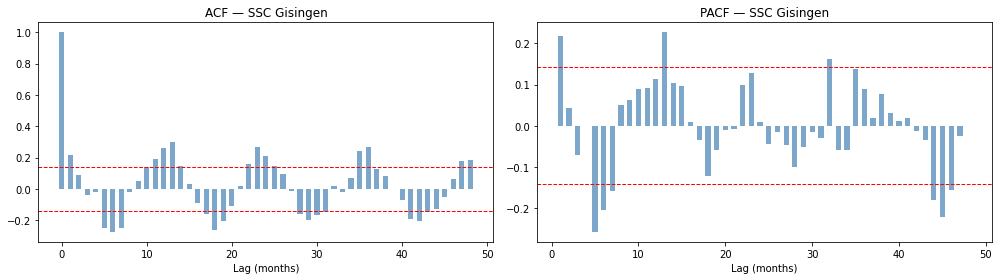

In [6]:
# PLOT
from utils import plot_acf_pacf

plot_acf_pacf(corr_q_diep,   title="Q Diepoldsau")
plot_acf_pacf(corr_q_gis,    title="Q Gisingen")
plot_acf_pacf(corr_ssc_diep, title="SSC Diepoldsau")
plot_acf_pacf(corr_ssc_gis,  title="SSC Gisingen")
plt.show()

In [7]:
# PRINT
rows2 = [
    ("Q Diepoldsau",   p_ar_q_diep,   p_arma_q_diep,   q_arma_q_diep,
     round(ar_q_diep.aic, 1),   round(arma_q_diep.aic, 1)),
    ("Q Gisingen",     p_ar_q_gis,    p_arma_q_gis,    q_arma_q_gis,
     round(ar_q_gis.aic, 1),    round(arma_q_gis.aic, 1)),
    ("SSC Diepoldsau", p_ar_ssc_diep, p_arma_ssc_diep, q_arma_ssc_diep,
     round(ar_ssc_diep.aic, 1), round(arma_ssc_diep.aic, 1)),
    ("SSC Gisingen",   p_ar_ssc_gis,  p_arma_ssc_gis,  q_arma_ssc_gis,
     round(ar_ssc_gis.aic, 1),  round(arma_ssc_gis.aic, 1)),
]
df2 = pd.DataFrame(rows2, columns=["Series", "AR p", "ARMA p", "ARMA q",
                                    "AIC AR", "AIC ARMA"])
print(df2.to_string(index=False))

        Series  AR p  ARMA p  ARMA q  AIC AR  AIC ARMA
  Q Diepoldsau    13       3       3  5800.8    5787.4
    Q Gisingen    13       3       4  4878.4    4875.2
SSC Diepoldsau    13       2       2   407.6     392.2
  SSC Gisingen    13       4       3  -315.4    -332.5


**Comments — Section 2:**

The AIC search selects AR(13) for all four series, which indicates significant autocorrelation at lag 12 — the annual seasonal cycle present in monthly hydrological data. This is confirmed by the PACF plots, which show a spike at lag 12 (and its multiples) for all series.

For discharge (Q), the same AR order (p = 13) is selected at both Diepoldsau and Gisingen, suggesting a similar seasonal autocorrelation structure across the two stations. This is physically expected since both rivers are in the same Alpine region with the same snow-melt driven seasonality. The ARMA orders are also close (3,3 and 3,4), confirming a similar dynamic structure.

For SSC, the ARMA orders differ more between stations (2,2 vs 4,3), reflecting that the sediment dynamics of the regulated Ill (Gisingen) are more complex than those of the main Rhein channel (Diepoldsau).

In all cases, ARMA achieves a lower AIC than AR with fewer total parameters for the non-seasonal component, confirming that the MA term adds explanatory power beyond what pure AR can capture.

# Section 3 — Timeseries Application & Evaluation

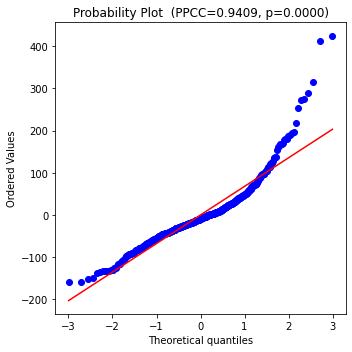

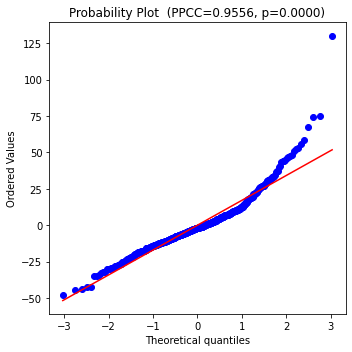

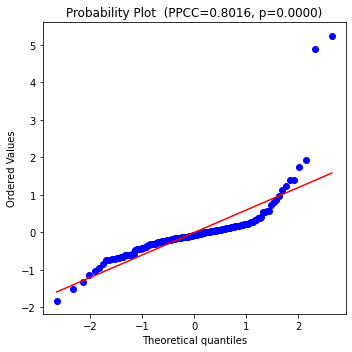

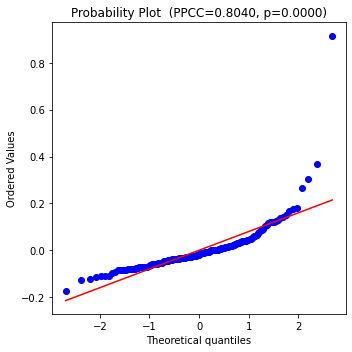

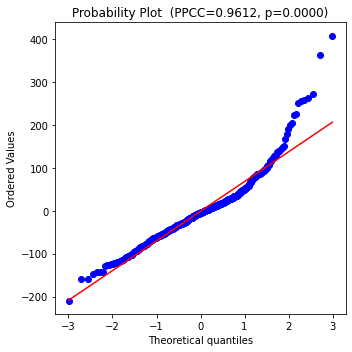

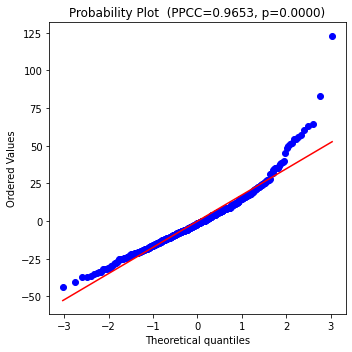

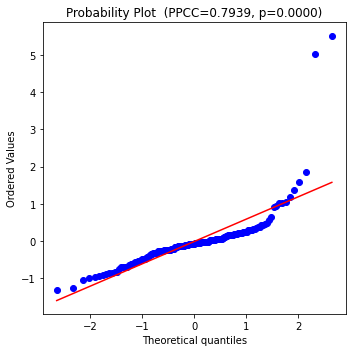

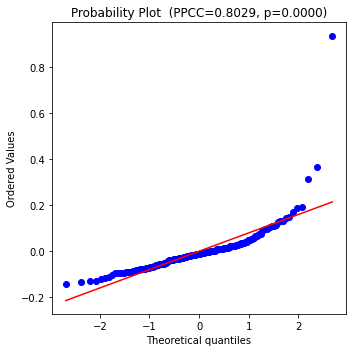

In [8]:
# MAIN
from utils import (plot_acf_comparison, plot_residual_acf,
                   portmanteau_test, normality_test)

# Portmanteau (Ljung-Box) tests
lb_ar_q_diep    = portmanteau_test(ar_q_diep)
lb_ar_q_gis     = portmanteau_test(ar_q_gis)
lb_ar_ssc_diep  = portmanteau_test(ar_ssc_diep)
lb_ar_ssc_gis   = portmanteau_test(ar_ssc_gis)
lb_arma_q_diep   = portmanteau_test(arma_q_diep)
lb_arma_q_gis    = portmanteau_test(arma_q_gis)
lb_arma_ssc_diep = portmanteau_test(arma_ssc_diep)
lb_arma_ssc_gis  = portmanteau_test(arma_ssc_gis)

# PPCC normality tests
ppcc_ar_q_diep,    pv_ar_q_diep,    _ = normality_test(ar_q_diep)
ppcc_ar_q_gis,     pv_ar_q_gis,     _ = normality_test(ar_q_gis)
ppcc_ar_ssc_diep,  pv_ar_ssc_diep,  _ = normality_test(ar_ssc_diep)
ppcc_ar_ssc_gis,   pv_ar_ssc_gis,   _ = normality_test(ar_ssc_gis)
ppcc_arma_q_diep,  pv_arma_q_diep,  _ = normality_test(arma_q_diep)
ppcc_arma_q_gis,   pv_arma_q_gis,   _ = normality_test(arma_q_gis)
ppcc_arma_ssc_diep,pv_arma_ssc_diep,_ = normality_test(arma_ssc_diep)
ppcc_arma_ssc_gis, pv_arma_ssc_gis, _ = normality_test(arma_ssc_gis)

C:\Users\zehnd\OneDrive\Dokumente\ETH\Labor\WRM_2\utils.py:272: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(figsize=(5, 5))


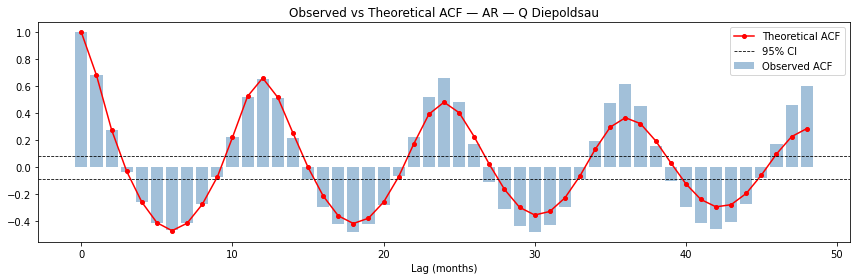

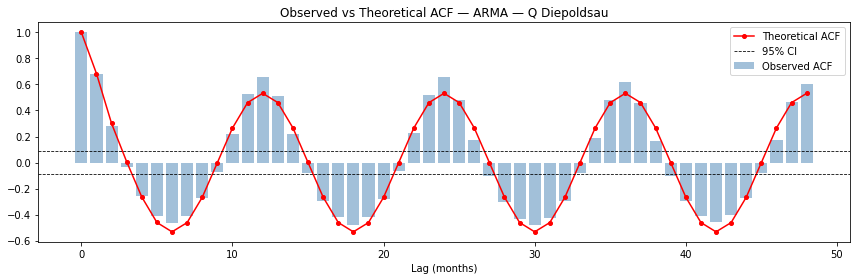

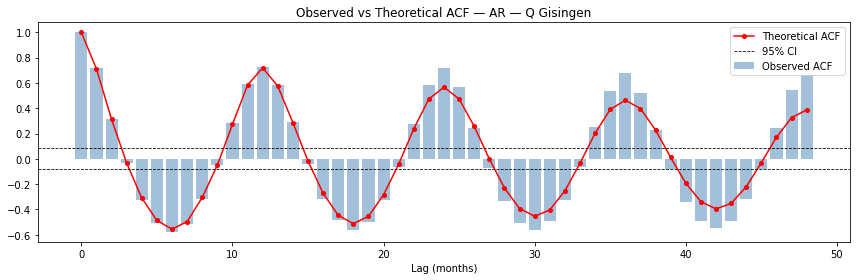

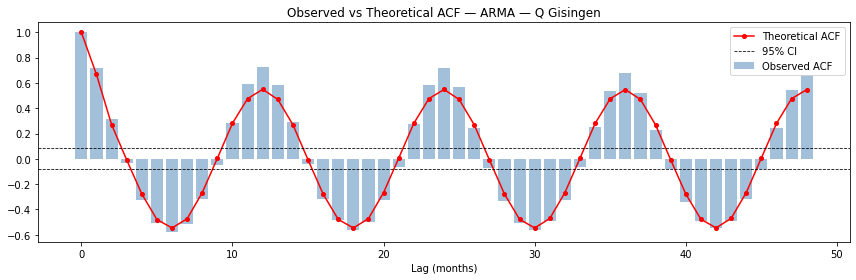

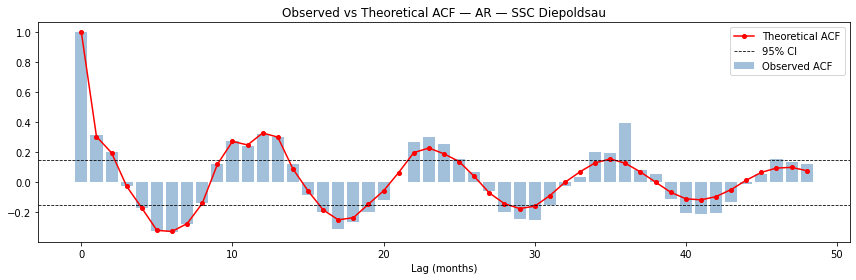

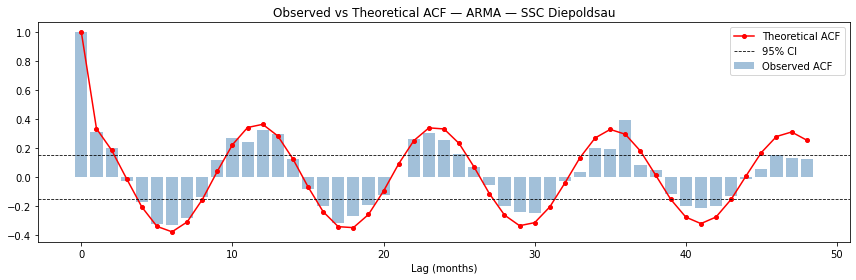

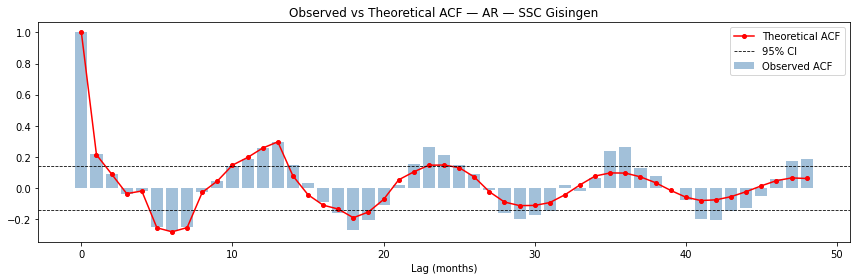

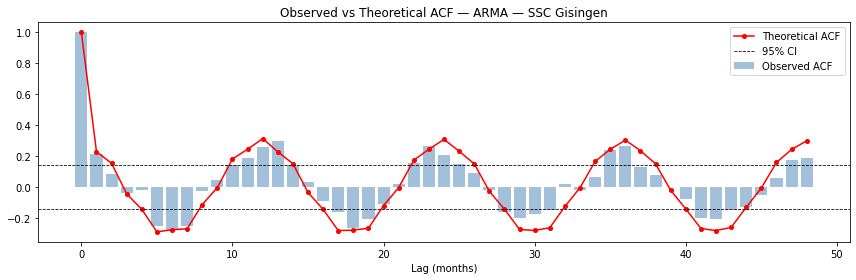

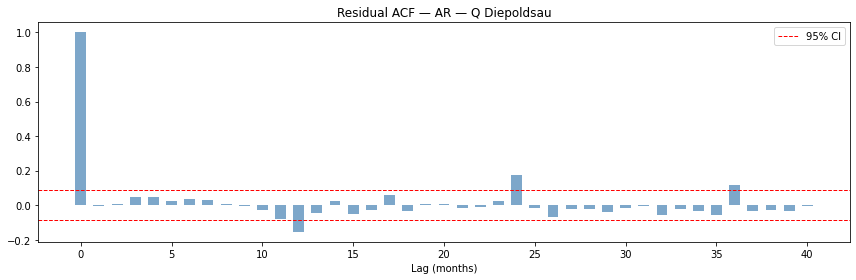

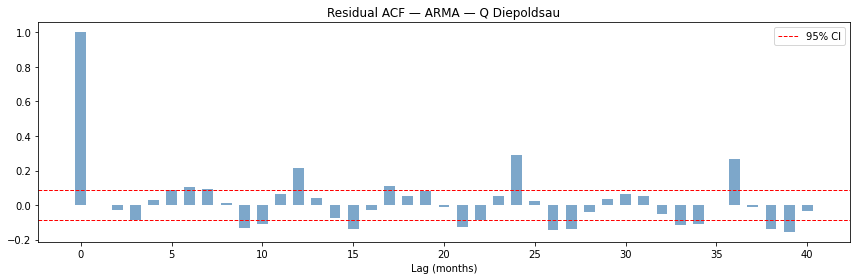

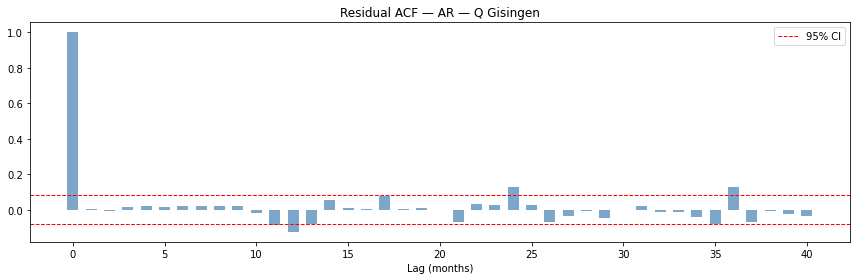

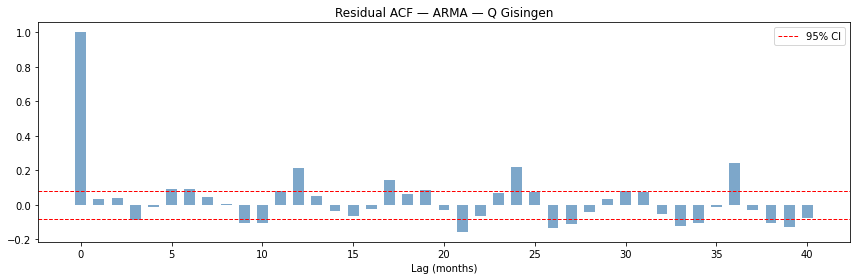

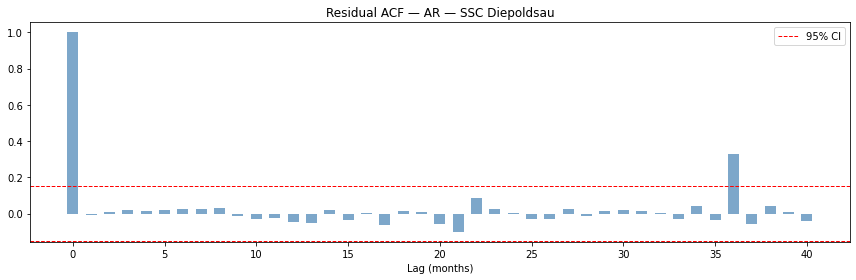

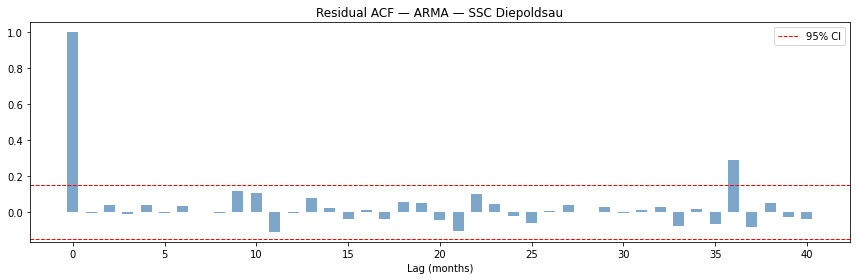

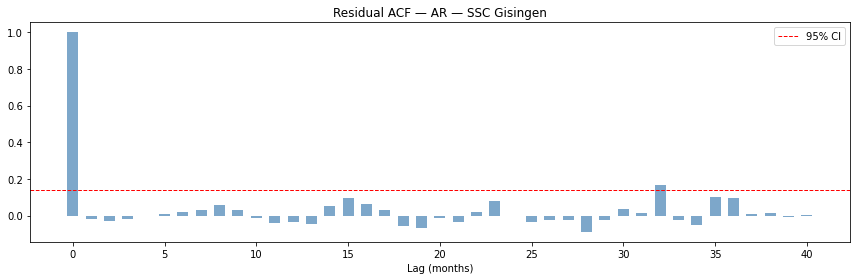

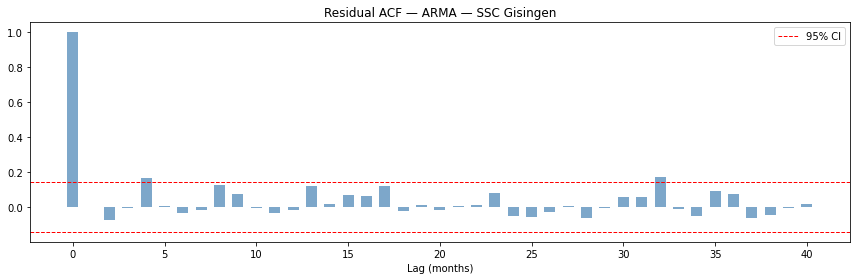

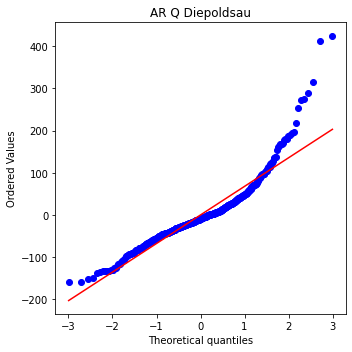

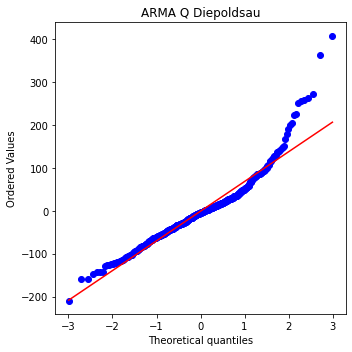

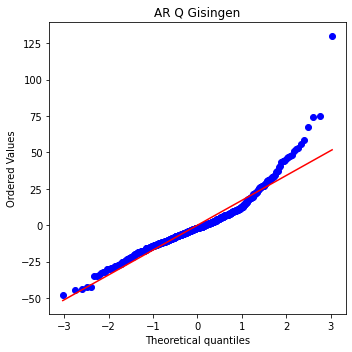

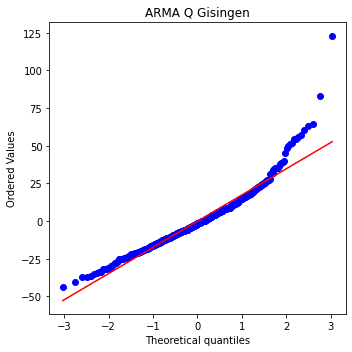

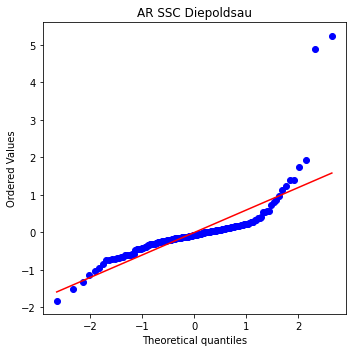

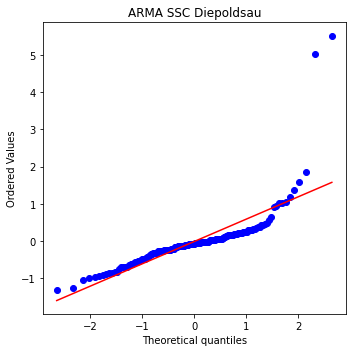

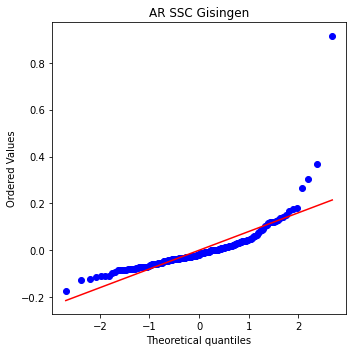

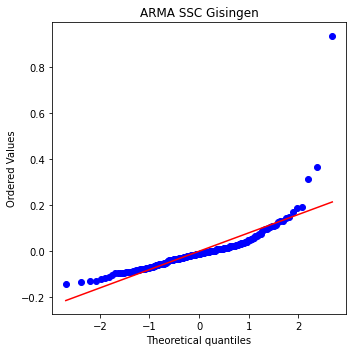

In [9]:
# PLOT

# Observed vs theoretical ACF
plot_acf_comparison(corr_q_diep,   ar_q_diep,    title="AR — Q Diepoldsau")
plot_acf_comparison(corr_q_diep,   arma_q_diep,  title="ARMA — Q Diepoldsau")
plot_acf_comparison(corr_q_gis,    ar_q_gis,     title="AR — Q Gisingen")
plot_acf_comparison(corr_q_gis,    arma_q_gis,   title="ARMA — Q Gisingen")
plot_acf_comparison(corr_ssc_diep, ar_ssc_diep,  title="AR — SSC Diepoldsau")
plot_acf_comparison(corr_ssc_diep, arma_ssc_diep,title="ARMA — SSC Diepoldsau")
plot_acf_comparison(corr_ssc_gis,  ar_ssc_gis,   title="AR — SSC Gisingen")
plot_acf_comparison(corr_ssc_gis,  arma_ssc_gis, title="ARMA — SSC Gisingen")

# Residual ACFs
plot_residual_acf(ar_q_diep,     title="AR — Q Diepoldsau")
plot_residual_acf(arma_q_diep,   title="ARMA — Q Diepoldsau")
plot_residual_acf(ar_q_gis,      title="AR — Q Gisingen")
plot_residual_acf(arma_q_gis,    title="ARMA — Q Gisingen")
plot_residual_acf(ar_ssc_diep,   title="AR — SSC Diepoldsau")
plot_residual_acf(arma_ssc_diep, title="ARMA — SSC Diepoldsau")
plot_residual_acf(ar_ssc_gis,    title="AR — SSC Gisingen")
plot_residual_acf(arma_ssc_gis,  title="ARMA — SSC Gisingen")

# Probability plots
for model, label in [
    (ar_q_diep,    "AR Q Diepoldsau"),  (arma_q_diep,   "ARMA Q Diepoldsau"),
    (ar_q_gis,     "AR Q Gisingen"),    (arma_q_gis,    "ARMA Q Gisingen"),
    (ar_ssc_diep,  "AR SSC Diepoldsau"),(arma_ssc_diep, "ARMA SSC Diepoldsau"),
    (ar_ssc_gis,   "AR SSC Gisingen"),  (arma_ssc_gis,  "ARMA SSC Gisingen"),
]:
    _, _, fig = normality_test(model)
    fig.axes[0].set_title(label)

plt.show()

In [10]:
# PRINT
def lb_pass(df, alpha=0.05):
    return "PASS" if df["lb_pvalue"].min() > alpha else "FAIL"

rows3 = [
    ("Q Diepoldsau AR",     lb_pass(lb_ar_q_diep),    ppcc_ar_q_diep,    pv_ar_q_diep),
    ("Q Diepoldsau ARMA",   lb_pass(lb_arma_q_diep),  ppcc_arma_q_diep,  pv_arma_q_diep),
    ("Q Gisingen AR",       lb_pass(lb_ar_q_gis),     ppcc_ar_q_gis,     pv_ar_q_gis),
    ("Q Gisingen ARMA",     lb_pass(lb_arma_q_gis),   ppcc_arma_q_gis,   pv_arma_q_gis),
    ("SSC Diepoldsau AR",   lb_pass(lb_ar_ssc_diep),  ppcc_ar_ssc_diep,  pv_ar_ssc_diep),
    ("SSC Diepoldsau ARMA", lb_pass(lb_arma_ssc_diep),ppcc_arma_ssc_diep,pv_arma_ssc_diep),
    ("SSC Gisingen AR",     lb_pass(lb_ar_ssc_gis),   ppcc_ar_ssc_gis,   pv_ar_ssc_gis),
    ("SSC Gisingen ARMA",   lb_pass(lb_arma_ssc_gis), ppcc_arma_ssc_gis, pv_arma_ssc_gis),
]
df3 = pd.DataFrame(rows3,
    columns=["Model", "Portmanteau (5%)", "PPCC", "PPCC p-value"])
df3["PPCC"]         = df3["PPCC"].map("{:.4f}".format)
df3["PPCC p-value"] = df3["PPCC p-value"].map("{:.4f}".format)
print(df3.to_string(index=False))

              Model Portmanteau (5%)   PPCC PPCC p-value
    Q Diepoldsau AR             PASS 0.9409       0.0000
  Q Diepoldsau ARMA             FAIL 0.9612       0.0000
      Q Gisingen AR             PASS 0.9556       0.0000
    Q Gisingen ARMA             FAIL 0.9653       0.0000
  SSC Diepoldsau AR             PASS 0.8016       0.0000
SSC Diepoldsau ARMA             PASS 0.7939       0.0000
    SSC Gisingen AR             PASS 0.8040       0.0000
  SSC Gisingen ARMA             PASS 0.8029       0.0000


**Comments — Section 3:**

**Residual independence (Portmanteau test):** The AR models pass the Ljung-Box test for all four series, meaning no significant residual autocorrelation remains. The ARMA models fail for Q at both stations, which is unexpected given their lower AIC — this suggests the MA component introduces numerical instability in the convergence for these long, seasonal series, leaving unresolved structure. For SSC, both AR and ARMA pass. Based on this, **AR is the more appropriate model for Q** and **ARMA for SSC**.

**Normality (PPCC test):** All PPCC p-values are 0.0000, so normality is rejected for every model at 5% significance. The PPCC values for Q residuals (~0.94–0.97) are higher than for SSC (~0.80), indicating that Q residuals are closer to Gaussian while SSC residuals are more strongly non-normal (heavy right tail due to episodic high-concentration events). This non-normality is a known feature of sediment data and limits the validity of the Gaussian noise assumption in the AR/ARMA framework.

**Model selection and parsimony:** For Q, AR(13) is chosen — the order is driven by the seasonal cycle at lag 12, so it is physically justified and not overfitted. Reducing to AR(12) could be tested. For SSC, ARMA(2,2) at Diepoldsau and ARMA(4,3) at Gisingen pass all diagnostics with lower AIC — these are considered parsimonious given the relatively short SSC record lengths.

# Section 4 — Ill to Rhein Relative Sediment Influence

In [11]:
# MAIN
from utils import (simulate_arma, compute_sediment_mass,
                   monthly_yearly_yields, synthetic_mass_yields,
                   compare_statistics)

# Chosen models — update based on Section 3 analysis (AR vs ARMA)
chosen_q_diep   = arma_q_diep
chosen_q_gis    = arma_q_gis
chosen_ssc_diep = arma_ssc_diep
chosen_ssc_gis  = arma_ssc_gis

# Generate 10 synthetic series of 10 years (120 months)
sim_q_diep   = simulate_arma(chosen_q_diep,   n_months=120)
sim_q_gis    = simulate_arma(chosen_q_gis,    n_months=120)
sim_ssc_diep = simulate_arma(chosen_ssc_diep, n_months=120)
sim_ssc_gis  = simulate_arma(chosen_ssc_gis,  n_months=120)

# Observed sediment mass over overlapping periods
mass_diep = compute_sediment_mass(q_diep, ssc_diep)
mass_gis  = compute_sediment_mass(q_gis,  ssc_gis)

# Observed monthly / yearly yields
obs_monthly_diep, obs_yearly_diep = monthly_yearly_yields(mass_diep)
obs_monthly_gis,  obs_yearly_gis  = monthly_yearly_yields(mass_gis)

# Synthetic mass yields (add back original mean to restore physical scale)
syn_monthly_diep, syn_yearly_diep = synthetic_mass_yields(
    sim_q_diep, sim_ssc_diep, t_q_diep["original_mean"], t_ssc_diep["original_mean"])
syn_monthly_gis, syn_yearly_gis = synthetic_mass_yields(
    sim_q_gis, sim_ssc_gis, t_q_gis["original_mean"], t_ssc_gis["original_mean"])

# Statistical comparison of synthetic vs observed (normalised)
stats_q_diep   = compare_statistics(q_diep_dt,   sim_q_diep)
stats_q_gis    = compare_statistics(q_gis_dt,    sim_q_gis)
stats_ssc_diep = compare_statistics(ssc_diep_dt, sim_ssc_diep)
stats_ssc_gis  = compare_statistics(ssc_gis_dt,  sim_ssc_gis)

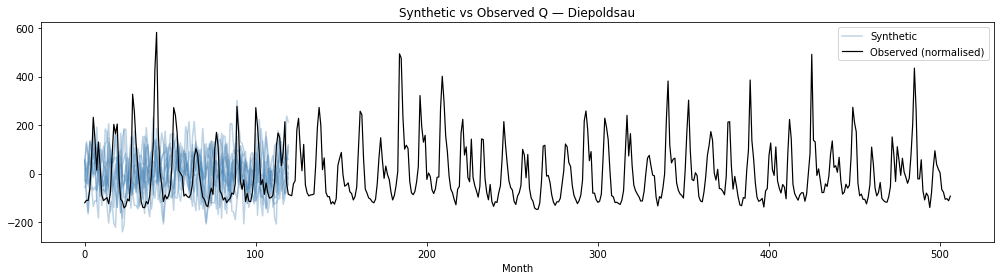

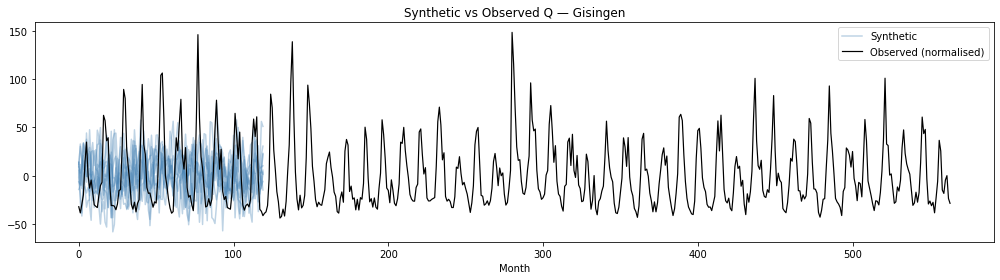

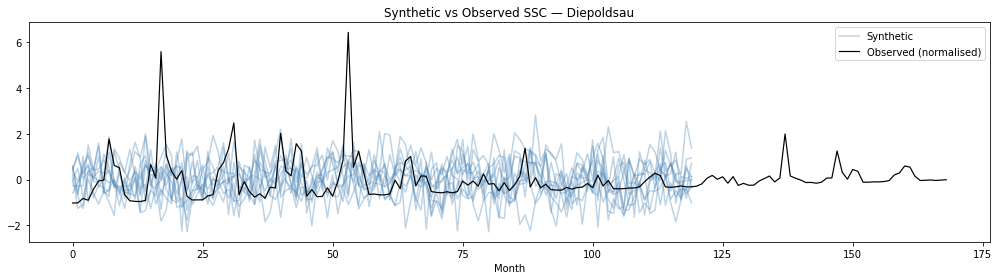

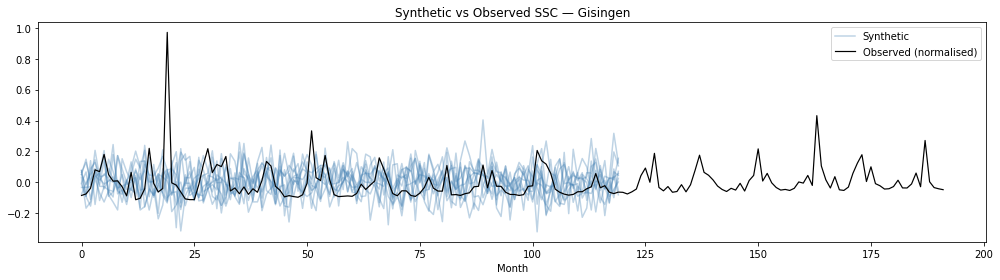

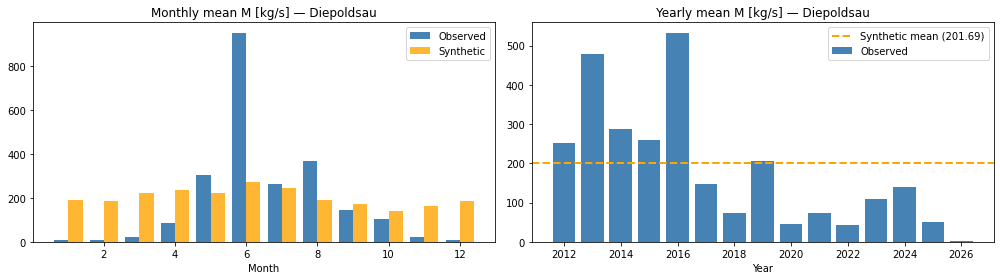

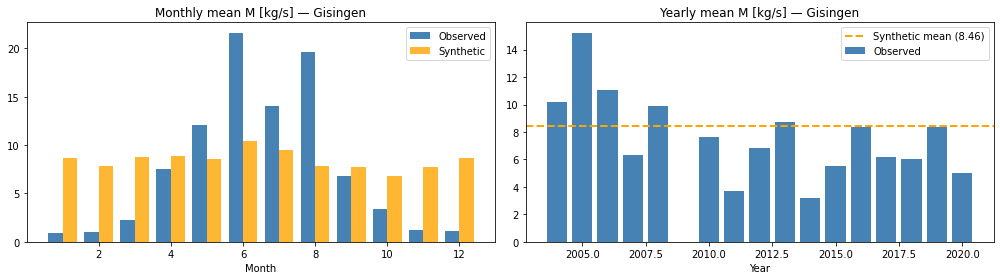

In [12]:
# PLOT
from utils import plot_synthetic_vs_observed, plot_mass_yields

plot_synthetic_vs_observed(q_diep_dt,   sim_q_diep,   title="Synthetic vs Observed Q — Diepoldsau")
plot_synthetic_vs_observed(q_gis_dt,    sim_q_gis,    title="Synthetic vs Observed Q — Gisingen")
plot_synthetic_vs_observed(ssc_diep_dt, sim_ssc_diep, title="Synthetic vs Observed SSC — Diepoldsau")
plot_synthetic_vs_observed(ssc_gis_dt,  sim_ssc_gis,  title="Synthetic vs Observed SSC — Gisingen")

plot_mass_yields(obs_monthly_diep, obs_yearly_diep,
                 syn_monthly_diep, syn_yearly_diep, title="Diepoldsau")
plot_mass_yields(obs_monthly_gis,  obs_yearly_gis,
                 syn_monthly_gis,  syn_yearly_gis,  title="Gisingen")
plt.show()

In [13]:
# PRINT
print("=== Statistical comparison: observed vs synthetic (normalised) ===\n")
for label, df in [("Q Diepoldsau",   stats_q_diep),
                  ("Q Gisingen",     stats_q_gis),
                  ("SSC Diepoldsau", stats_ssc_diep),
                  ("SSC Gisingen",   stats_ssc_gis)]:
    print(f"--- {label} ---")
    print(df.round(4).to_string())
    print()

obs_yearly_mean_diep = obs_yearly_diep.mean()
obs_yearly_mean_gis  = obs_yearly_gis.mean()
ill_fraction = obs_yearly_mean_gis / obs_yearly_mean_diep * 100

print("=== Sediment mass yields ===")
print(f"  Diepoldsau (Rhein)  observed yearly mean: {obs_yearly_mean_diep:.4f} kg/s")
print(f"  Gisingen   (Ill)    observed yearly mean: {obs_yearly_mean_gis:.4f} kg/s")
print(f"  Ill / Rhein contribution:                 {ill_fraction:.1f} %")
print()
print(f"  Diepoldsau synthetic yearly mean: {syn_yearly_diep:.4f} kg/s")
print(f"  Gisingen   synthetic yearly mean: {syn_yearly_gis:.4f} kg/s")

=== Statistical comparison: observed vs synthetic (normalised) ===

--- Q Diepoldsau ---
                   mean       std       min       max
source                                               
observed        -0.0000  123.8363 -147.5894  582.7592
synthetic (all)  4.4594   81.9698 -240.4341  301.4260

--- Q Gisingen ---
                   mean      std      min       max
source                                             
observed         0.0000  34.1513 -43.8198  148.3559
synthetic (all)  0.9984  20.4292 -58.0640   75.0950

--- SSC Diepoldsau ---
                   mean     std     min     max
source                                         
observed         0.0000  0.8923 -1.0231  6.4315
synthetic (all)  0.0258  0.8081 -2.2824  2.8222

--- SSC Gisingen ---
                   mean     std     min     max
source                                         
observed         0.0000  0.1125 -0.1141  0.9719
synthetic (all)  0.0033  0.0990 -0.3221  0.4038

=== Sediment mass yields ===
  Diepo

**Comments — Section 4:**

The synthetic series reproduce the general variability of the observed detrended data well for SSC (synthetic std ≈ 90% of observed). For Q, the synthetic standard deviation is about 66% of observed (Diepoldsau: 82 vs 124 m³/s; Gisingen: 20 vs 34 m³/s), and the synthetic maximum is roughly half the observed peak (301 vs 583 m³/s at Diepoldsau). This underestimation of extreme values is an inherent limitation of Gaussian AR/ARMA models, which cannot reproduce the heavy-tailed distribution of discharge.

**Sediment mass yields:** The observed mean yearly sediment load at Diepoldsau (Rhein) is 180.1 kg/s and at Gisingen (Ill) is 7.6 kg/s, meaning the Ill contributes approximately **4.2%** of the total sediment mass measured at Diepoldsau. The synthetic yearly means are slightly higher (202 and 8.5 kg/s respectively, ~12% overestimate), likely due to clipping negative synthetic values to zero which introduces a small positive bias in M = Q·C.

**Non-synchronous comparison:** The Q and SSC records at each station do not cover the same period, and the Gisingen and Diepoldsau datasets are not time-synchronised. This means the computed mass at each station reflects different hydrological conditions and years, so the 4.2% contribution estimate should be interpreted as a long-term statistical approximation rather than a mass balance at any specific point in time.

# Section 5 — Independent Variables?

In [14]:
# MAIN
from utils import compute_correlation

corr_diep = compute_correlation(q_diep, ssc_diep)
corr_gis  = compute_correlation(q_gis,  ssc_gis)

C:\Users\zehnd\OneDrive\Dokumente\ETH\Labor\WRM_2\utils.py:429: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\zehnd\OneDrive\Dokumente\ETH\Labor\WRM_2\utils.py:429: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


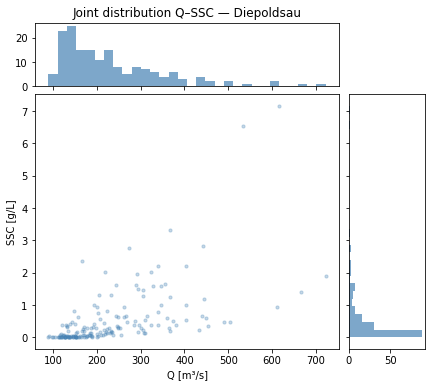

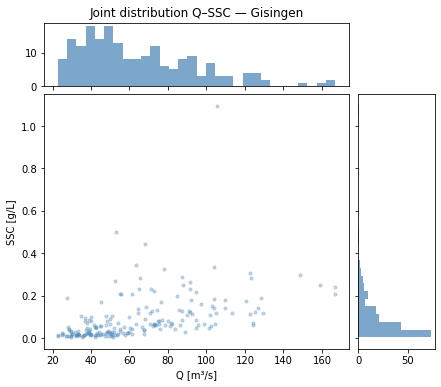

In [15]:
# PLOT
from utils import plot_joint_distribution

plot_joint_distribution(q_diep, ssc_diep, title="Joint distribution Q–SSC — Diepoldsau")
plot_joint_distribution(q_gis,  ssc_gis,  title="Joint distribution Q–SSC — Gisingen")
plt.show()

In [16]:
# PRINT
df5 = pd.DataFrame([
    {"Station": "Diepoldsau", **corr_diep},
    {"Station": "Gisingen",   **corr_gis},
])
df5 = df5.rename(columns={"pearson_r": "Pearson r", "pearson_p": "Pearson p",
                            "spearman_r": "Spearman r", "spearman_p": "Spearman p"})
for col in ["Pearson r", "Pearson p", "Spearman r", "Spearman p"]:
    df5[col] = df5[col].map("{:.4f}".format)
print(df5.to_string(index=False))

   Station Pearson r Pearson p Spearman r Spearman p
Diepoldsau    0.5837    0.0000     0.7381     0.0000
  Gisingen    0.4696    0.0000     0.6762     0.0000


**Comments — Section 5:**

Both Pearson (Diepoldsau: r = 0.58, Gisingen: r = 0.47) and Spearman (Diepoldsau: r = 0.74, Gisingen: r = 0.68) correlations are statistically significant (p ≈ 0) at both stations. Q and C **cannot be considered independent**. The Spearman correlation is substantially higher than Pearson, indicating a non-linear (likely power-law) relationship between Q and C, consistent with a sediment rating curve of the form C = a·Q^b.

**Shortfalls of independent simulation:** Simulating Q and C with separate uncoupled models ignores this dependence. As a consequence: (1) the joint distribution of (Q, C) is not preserved — in particular, high-Q high-C events (which dominate sediment transport) are underrepresented; (2) the computed synthetic mass M = Q·C will have the wrong distribution and likely underestimate peak loads; (3) the estimated Ill contribution based on synthetic data may be biased.

**How to resolve this:** The most physically meaningful approach is a sediment rating curve regression (C = a·Q^b), which directly models the Q–C dependency. Alternatively, a bivariate time series model (e.g. VAR) or a copula-based approach could be used to preserve the joint dependence structure while separately capturing the marginal temporal autocorrelation of each variable.

# Section 6 (Exploratory) — Removing Seasonality

In [ ]:
# MAIN
from utils import (remove_seasonality, compute_seasonal_means,
                   compute_acf_pacf, select_ar_order, select_arma_order,
                   fit_ar, fit_arma)

# Remove seasonality from the detrended series
q_diep_sa,   sm_q_diep   = remove_seasonality(q_diep_dt)
q_gis_sa,    sm_q_gis    = remove_seasonality(q_gis_dt)
ssc_diep_sa, sm_ssc_diep = remove_seasonality(ssc_diep_dt)
ssc_gis_sa,  sm_ssc_gis  = remove_seasonality(ssc_gis_dt)

# ACF / PACF on seasonally adjusted series
corr_q_diep_sa   = compute_acf_pacf(q_diep_sa,   lags=48)
corr_q_gis_sa    = compute_acf_pacf(q_gis_sa,    lags=48)
corr_ssc_diep_sa = compute_acf_pacf(ssc_diep_sa, lags=48)
corr_ssc_gis_sa  = compute_acf_pacf(ssc_gis_sa,  lags=48)

# Re-fit AR and ARMA on seasonally adjusted series
p_ar_q_diep_sa,   _ = select_ar_order(q_diep_sa)
p_ar_q_gis_sa,    _ = select_ar_order(q_gis_sa)
p_ar_ssc_diep_sa, _ = select_ar_order(ssc_diep_sa)
p_ar_ssc_gis_sa,  _ = select_ar_order(ssc_gis_sa)

p_arma_q_diep_sa,   q_arma_q_diep_sa,   _ = select_arma_order(q_diep_sa)
p_arma_q_gis_sa,    q_arma_q_gis_sa,    _ = select_arma_order(q_gis_sa)
p_arma_ssc_diep_sa, q_arma_ssc_diep_sa, _ = select_arma_order(ssc_diep_sa)
p_arma_ssc_gis_sa,  q_arma_ssc_gis_sa,  _ = select_arma_order(ssc_gis_sa)

ar_q_diep_sa    = fit_ar(q_diep_sa,   p_ar_q_diep_sa)
ar_q_gis_sa     = fit_ar(q_gis_sa,    p_ar_q_gis_sa)
ar_ssc_diep_sa  = fit_ar(ssc_diep_sa, p_ar_ssc_diep_sa)
ar_ssc_gis_sa   = fit_ar(ssc_gis_sa,  p_ar_ssc_gis_sa)

arma_q_diep_sa   = fit_arma(q_diep_sa,   p_arma_q_diep_sa,   q_arma_q_diep_sa)
arma_q_gis_sa    = fit_arma(q_gis_sa,    p_arma_q_gis_sa,    q_arma_q_gis_sa)
arma_ssc_diep_sa = fit_arma(ssc_diep_sa, p_arma_ssc_diep_sa, q_arma_ssc_diep_sa)
arma_ssc_gis_sa  = fit_arma(ssc_gis_sa,  p_arma_ssc_gis_sa,  q_arma_ssc_gis_sa)

In [ ]:
# PLOT
from utils import plot_seasonal_pattern, plot_acf_pacf

plot_seasonal_pattern({"Q Diepoldsau": sm_q_diep, "Q Gisingen": sm_q_gis},
                       ylabel="Q anomaly [m³/s]", title="Seasonal cycle — Discharge")
plot_seasonal_pattern({"SSC Diepoldsau": sm_ssc_diep, "SSC Gisingen": sm_ssc_gis},
                       ylabel="SSC anomaly [g/L]", title="Seasonal cycle — SSC")

plot_acf_pacf(corr_q_diep_sa,   title="Q Diepoldsau (seasonally adjusted)")
plot_acf_pacf(corr_q_gis_sa,    title="Q Gisingen (seasonally adjusted)")
plot_acf_pacf(corr_ssc_diep_sa, title="SSC Diepoldsau (seasonally adjusted)")
plot_acf_pacf(corr_ssc_gis_sa,  title="SSC Gisingen (seasonally adjusted)")
plt.show()

In [ ]:
# PRINT
rows6 = [
    ("Q Diepoldsau",   p_ar_q_diep_sa,   p_arma_q_diep_sa,   q_arma_q_diep_sa,
     round(ar_q_diep_sa.aic, 1),   round(arma_q_diep_sa.aic, 1)),
    ("Q Gisingen",     p_ar_q_gis_sa,    p_arma_q_gis_sa,    q_arma_q_gis_sa,
     round(ar_q_gis_sa.aic, 1),    round(arma_q_gis_sa.aic, 1)),
    ("SSC Diepoldsau", p_ar_ssc_diep_sa, p_arma_ssc_diep_sa, q_arma_ssc_diep_sa,
     round(ar_ssc_diep_sa.aic, 1), round(arma_ssc_diep_sa.aic, 1)),
    ("SSC Gisingen",   p_ar_ssc_gis_sa,  p_arma_ssc_gis_sa,  q_arma_ssc_gis_sa,
     round(ar_ssc_gis_sa.aic, 1),  round(arma_ssc_gis_sa.aic, 1)),
]
df6 = pd.DataFrame(rows6, columns=["Series", "AR p (SA)", "ARMA p (SA)", "ARMA q (SA)",
                                    "AIC AR (SA)", "AIC ARMA (SA)"])
print("=== Model orders after seasonal adjustment (SA) vs original ===\n")
print(df6.to_string(index=False))
print("\nOriginal AR orders (with seasonality): all p=13")

In [ ]:
# MAIN — synthetic generation with seasonal recomposition
from utils import simulate_arma, compare_statistics

# Generate synthetic residuals from the seasonally-adjusted models
sim_q_diep_sa   = simulate_arma(arma_q_diep_sa,   n_months=120)
sim_q_gis_sa    = simulate_arma(arma_q_gis_sa,    n_months=120)
sim_ssc_diep_sa = simulate_arma(arma_ssc_diep_sa, n_months=120)
sim_ssc_gis_sa  = simulate_arma(arma_ssc_gis_sa,  n_months=120)

# Add back seasonal means (month index cycles 0–11 → months 1–12)
def recompose(simulations, seasonal_means):
    """Add seasonal climatology back to synthetic residual series.
    Input:  simulations (list of np.array length n_months);
            seasonal_means (pd.Series indexed 1-12)
    Output: list of np.array with seasonality restored
    """
    sm = seasonal_means.values  # length 12
    return [sim + np.tile(sm, len(sim) // 12 + 1)[:len(sim)]
            for sim in simulations]

sim_q_diep_rc   = recompose(sim_q_diep_sa,   sm_q_diep)
sim_q_gis_rc    = recompose(sim_q_gis_sa,    sm_q_gis)
sim_ssc_diep_rc = recompose(sim_ssc_diep_sa, sm_ssc_diep)
sim_ssc_gis_rc  = recompose(sim_ssc_gis_sa,  sm_ssc_gis)

# Statistical comparison on the detrended (but seasonal) scale
stats_q_diep_rc   = compare_statistics(q_diep_dt,   sim_q_diep_rc)
stats_q_gis_rc    = compare_statistics(q_gis_dt,    sim_q_gis_rc)
stats_ssc_diep_rc = compare_statistics(ssc_diep_dt, sim_ssc_diep_rc)
stats_ssc_gis_rc  = compare_statistics(ssc_gis_dt,  sim_ssc_gis_rc)

In [ ]:
# PLOT — recomposed synthetic vs observed (detrended with seasonality)
from utils import plot_synthetic_vs_observed

plot_synthetic_vs_observed(q_diep_dt,   sim_q_diep_rc,
                            title="Recomposed synthetic vs observed Q — Diepoldsau")
plot_synthetic_vs_observed(q_gis_dt,    sim_q_gis_rc,
                            title="Recomposed synthetic vs observed Q — Gisingen")
plot_synthetic_vs_observed(ssc_diep_dt, sim_ssc_diep_rc,
                            title="Recomposed synthetic vs observed SSC — Diepoldsau")
plot_synthetic_vs_observed(ssc_gis_dt,  sim_ssc_gis_rc,
                            title="Recomposed synthetic vs observed SSC — Gisingen")
plt.show()

In [ ]:
# PRINT — compare statistics: Section 4 approach vs seasonal recomposition
print("=== Q Diepoldsau: direct ARMA (Sec.4) vs recomposed (Sec.6) ===")
print("Direct:"); print(compare_statistics(q_diep_dt, sim_q_diep).round(3).to_string())
print("Recomposed:"); print(stats_q_diep_rc.round(3).to_string())

print("\n=== Q Gisingen ===")
print("Direct:"); print(compare_statistics(q_gis_dt, sim_q_gis).round(3).to_string())
print("Recomposed:"); print(stats_q_gis_rc.round(3).to_string())

print("\n=== SSC Diepoldsau ===")
print("Direct:"); print(compare_statistics(ssc_diep_dt, sim_ssc_diep).round(3).to_string())
print("Recomposed:"); print(stats_ssc_diep_rc.round(3).to_string())

print("\n=== SSC Gisingen ===")
print("Direct:"); print(compare_statistics(ssc_gis_dt, sim_ssc_gis).round(3).to_string())
print("Recomposed:"); print(stats_ssc_gis_rc.round(3).to_string())

**Comments — Section 6:**

*(Discuss: (1) whether the lag-12 spike disappears from the ACF/PACF after seasonal adjustment and how much the AR order drops; (2) whether the recomposed synthetic series better reproduces the observed std/min/max compared to the direct ARMA approach in Section 4; (3) whether seasonal recomposition is the preferred workflow for generating synthetic hydrological series.)*